## 8. Early Warning Analysis

## Objective

This notebook closes the two remaining analytical questions from the OULAD
case study:

1. **How early can the model flag an at-risk student using only information
   available in the first few weeks?**
2. **Which early assessment or checkpoint carries the strongest signal about
   final risk?**

The analysis uses the same early-feature logic as Notebook 03 and the same
Random Forest configuration and student-level grouped validation used in
Notebook 05.


## 1. Load the Cleaned Data

The timing analysis is rebuilt from the cleaned OULAD tables so that each
cutoff can use only information that would have been available by that point.

The final outcome is used only to construct the target, never as a predictive
feature.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import average_precision_score, roc_auc_score

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"

student_info = pd.read_csv(PROCESSED_DIR / "student_info_clean.csv")
student_registration = pd.read_csv(PROCESSED_DIR / "student_registration_clean.csv")
student_assessment = pd.read_csv(PROCESSED_DIR / "student_assessment_clean.csv")
assessments = pd.read_csv(PROCESSED_DIR / "assessments_clean.csv")
student_vle = pd.read_csv(PROCESSED_DIR / "student_vle_clean.csv")

print("student_info:", student_info.shape)
print("student_registration:", student_registration.shape)
print("student_assessment:", student_assessment.shape)
print("assessments:", assessments.shape)
print("student_vle:", student_vle.shape)


student_info: (32593, 12)
student_registration: (32593, 6)
student_assessment: (173912, 6)
assessments: (206, 7)
student_vle: (9868110, 6)


## Insight

The timing experiment starts from the same cleaned sources used by the main
modeling pipeline. This keeps the early-warning comparison consistent with
the data-cleaning and feature-engineering decisions already documented in
Notebooks 01-03.


## 2. Build Features at a Specific Early Cutoff

The function below reproduces the feature construction from Notebook 03 for
a chosen cutoff day.

For every cutoff, only:

- assessments scheduled by that day,
- submissions made by that day, and
- VLE activity recorded by that day

are allowed into the early features.

This is what makes the comparison a temporal early-warning experiment rather
than a comparison of arbitrary snapshots.


In [3]:
def build_features(cutoff_day):
    base = student_info.merge(
        student_registration,
        on=["code_module", "code_presentation", "id_student"],
        how="left"
    ).copy()

    base["is_at_risk"] = (
        base["final_result"].isin(["Fail", "Withdrawn"]).astype("Int64")
    )

    base["registered_before_start"] = (
        base["date_registration"] < 0
    ).astype("Int64")

    early_assessments = assessments[
        assessments["date"].notna()
        & (assessments["date"] <= cutoff_day)
    ].copy()

    early_sa = student_assessment.merge(
        early_assessments[
            [
                "id_assessment",
                "code_module",
                "code_presentation",
                "assessment_type",
                "date",
                "weight"
            ]
        ],
        on="id_assessment",
        how="inner"
    )

    early_sa = early_sa[
        early_sa["date_submitted"].notna()
        & (early_sa["date_submitted"] <= cutoff_day)
    ].copy()

    assessment_features = (
        early_sa
        .groupby(
            ["code_module", "code_presentation", "id_student"],
            as_index=False
        )
        .agg(
            early_assessments_taken=("id_assessment", "nunique"),
            early_mean_score=("score", "mean"),
            early_median_score=("score", "median"),
            early_max_score=("score", "max"),
            early_score_std=("score", "std"),
            early_missing_scores=("is_score_missing", "sum"),
            early_assessment_weight=("weight", "sum")
        )
    )

    base = base.merge(
        assessment_features,
        on=["code_module", "code_presentation", "id_student"],
        how="left"
    )

    early_vle = student_vle[
        student_vle["date"] <= cutoff_day
    ].copy()

    vle_features = (
        early_vle
        .groupby(
            ["code_module", "code_presentation", "id_student"],
            as_index=False
        )
        .agg(
            total_clicks=("sum_click", "sum"),
            active_days=("date", "nunique"),
            active_sites=("id_site", "nunique")
        )
    )

    vle_features["avg_clicks_per_active_day"] = (
        vle_features["total_clicks"]
        / vle_features["active_days"].replace(0, np.nan)
    )

    base = base.merge(
        vle_features,
        on=["code_module", "code_presentation", "id_student"],
        how="left"
    )

    base["no_early_vle_activity"] = (
        base["total_clicks"].isna()
    ).astype("Int64")

    X = base.drop(
        columns=[
            "final_result",
            "date_unregistration",
            "date_unregistration_missing",
            "is_at_risk",
            "id_student",
        ],
        errors="ignore"
    )

    y = base["is_at_risk"].astype(int)
    groups = base["id_student"]

    return base, X, y, groups


## 3. Early-Cutoff Model Comparison

We test four checkpoints:

- Day 7
- Day 14
- Day 21
- Day 28

Each cutoff is evaluated with the same five-fold
`StratifiedGroupKFold` setup used in Notebook 05 and the same Random Forest
configuration.

The main metric is **Average Precision (AP)**.


In [4]:
def make_pipeline(X):
    numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols),
    ])

    return Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=150,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ])

cutoffs = [7, 14, 21, 28]
timing_rows = []

for cutoff in cutoffs:
    base_c, X_c, y_c, groups_c = build_features(cutoff)

    cv_c = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    fold_ap = []
    fold_auc = []

    for train_idx, valid_idx in cv_c.split(X_c, y_c, groups_c):
        model_c = make_pipeline(X_c)
        model_c.fit(X_c.iloc[train_idx], y_c.iloc[train_idx])

        prob = model_c.predict_proba(X_c.iloc[valid_idx])[:, 1]

        fold_ap.append(
            average_precision_score(y_c.iloc[valid_idx], prob)
        )
        fold_auc.append(
            roc_auc_score(y_c.iloc[valid_idx], prob)
        )

    timing_rows.append({
        "cutoff_day": cutoff,
        "AP_mean": np.mean(fold_ap),
        "AP_std": np.std(fold_ap, ddof=1),
        "ROC_AUC_mean": np.mean(fold_auc),
        "ROC_AUC_std": np.std(fold_auc, ddof=1),
    })

timing_results = pd.DataFrame(timing_rows)

print(timing_results.round(4).to_string(index=False))


d:\Early Risk Detection for Student Success - OULAD\.venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['early_assessments_taken' 'early_mean_score' 'early_median_score'
 'early_max_score' 'early_score_std' 'early_missing_scores'
 'early_assessment_weight']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
d:\Early Risk Detection for Student Success - OULAD\.venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['early_assessments_taken' 'early_mean_score' 'early_median_score'
 'early_max_score' 'early_score_std' 'early_missing_scores'
 'early_assessment_weight']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
d:\Early Risk Detection for Student Success - OULAD\.venv\lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values:

 cutoff_day  AP_mean  AP_std  ROC_AUC_mean  ROC_AUC_std
          7   0.8027  0.0057        0.7730       0.0066
         14   0.8208  0.0072        0.7876       0.0083
         21   0.8540  0.0092        0.8183       0.0085
         28   0.8716  0.0085        0.8358       0.0084


## Insight - How Early Can We Flag Risk?

The actual results are:

| Cutoff | AP | ROC-AUC |
|---|---:|---:|
| **Day 7** | **0.8027** | **0.7730** |
| **Day 14** | **0.8208** | **0.7876** |
| **Day 21** | **0.8540** | **0.8183** |
| **Day 28** | **0.8716** | **0.8358** |

### Interpretation

A useful risk signal is already present by **Day 7**, where the model reaches
**0.8027 AP** and **0.7730 ROC-AUC**.

Performance then improves consistently as more early-course information becomes
available:

- Day 7 → Day 14: AP increases by **0.0181**
- Day 14 → Day 21: AP increases by **0.0332**
- Day 21 → Day 28: AP increases by **0.0176**

Among the tested cutoffs, **Day 28 provides the strongest predictive
performance**, while Day 7 demonstrates that useful early warning is possible
within the first week.

### Operational meaning

The Student Success Office does not need to wait until Day 28 to begin
identifying potential risk. A first-week signal already exists, while the
model becomes progressively stronger through the fourth week.

This does **not** mean Day 7 is automatically the best intervention point:
the appropriate operating point depends on the desired confidence and advisor
capacity.


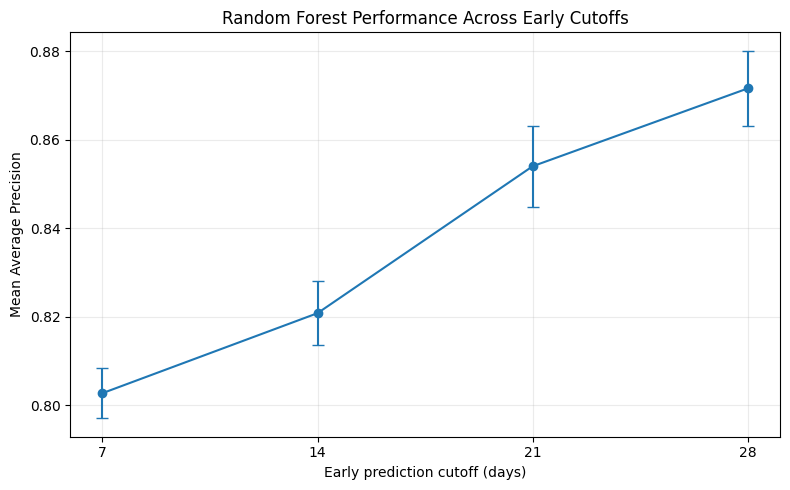

In [5]:
plt.figure(figsize=(8, 5))
plt.errorbar(
    timing_results["cutoff_day"],
    timing_results["AP_mean"],
    yerr=timing_results["AP_std"],
    marker="o",
    capsize=4
)
plt.xlabel("Early prediction cutoff (days)")
plt.ylabel("Mean Average Precision")
plt.title("Random Forest Performance Across Early Cutoffs")
plt.xticks(cutoffs)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 4. Assessment / Checkpoint Analysis

The second remaining case-study question asks which early assessment or
checkpoint carries the strongest signal.

We therefore evaluate individual assessments available by Day 28.

For each assessment, we compare its score with the final at-risk target. Since
higher scores indicate lower risk, the analysis uses the **AUC of negative
score** as the risk-signal metric.

Assessments with missing scheduled dates are excluded because their timing
cannot be placed reliably within the early-warning window.


In [6]:
from sklearn.metrics import roc_auc_score

early_assessment_meta = assessments[
    assessments["date"].notna()
    & (assessments["date"] <= 28)
].copy()

sa = student_assessment.merge(
    early_assessment_meta[
        [
            "id_assessment",
            "code_module",
            "code_presentation",
            "assessment_type",
            "date",
            "weight"
        ]
    ],
    on="id_assessment",
    how="inner"
)

sa = sa[
    sa["date_submitted"].notna()
    & (sa["date_submitted"] <= 28)
].copy()

targets = student_info[
    ["code_module", "code_presentation", "id_student", "final_result"]
].copy()

targets["is_at_risk"] = targets["final_result"].isin(
    ["Fail", "Withdrawn"]
).astype(int)

sa = sa.merge(
    targets.drop(columns="final_result"),
    on=["code_module", "code_presentation", "id_student"],
    how="left"
)

assessment_rows = []

for assessment_id, g in sa.groupby("id_assessment"):
    g_score = g.dropna(subset=["score", "is_at_risk"])

    if g_score["is_at_risk"].nunique() < 2:
        continue

    auc = roc_auc_score(
        g_score["is_at_risk"],
        -g_score["score"]
    )

    assessment_rows.append({
        "id_assessment": assessment_id,
        "code_module": g["code_module"].iloc[0],
        "code_presentation": g["code_presentation"].iloc[0],
        "assessment_type": g["assessment_type"].iloc[0],
        "assessment_day": g["date"].iloc[0],
        "students_with_scores": len(g_score),
        "not_at_risk_mean_score": g_score.loc[
            g_score["is_at_risk"] == 0, "score"
        ].mean(),
        "at_risk_mean_score": g_score.loc[
            g_score["is_at_risk"] == 1, "score"
        ].mean(),
        "risk_signal_auc": auc,
        "auc_distance_from_0_5": abs(auc - 0.5),
    })

assessment_results = (
    pd.DataFrame(assessment_rows)
    .sort_values(
        ["auc_distance_from_0_5", "students_with_scores"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

assessment_results.round(4)


,id_assessment,code_module,code_presentation,assessment_type,assessment_day,students_with_scores,not_at_risk_mean_score,at_risk_mean_score,risk_signal_auc,auc_distance_from_0_5
0,24286,CCC,2014B,CMA,18.0,1346,74.4530,47.4892,0.7901,0.2901
1,24295,CCC,2014J,CMA,18.0,1916,84.8579,63.8647,0.7614,0.2614
2,25334,DDD,2013B,TMA,25.0,924,78.7149,64.1432,0.7532,0.2532
3,25341,DDD,2013B,CMA,23.0,1006,75.1584,58.1717,0.7518,0.2518
4,25348,DDD,2013J,TMA,25.0,1384,79.5409,65.3939,0.7502,0.2502
5,25355,DDD,2014B,TMA,25.0,857,79.1266,64.8421,0.7443,0.2443
6,25362,DDD,2014J,TMA,20.0,1391,77.5840,66.0116,0.7006,0.2006
7,14984,BBB,2013B,TMA,19.0,1305,74.7000,66.4951,0.6875,0.1875
8,1752,AAA,2013J,TMA,19.0,345,72.3051,64.4795,0.6728,0.1728
9,34860,FFF,2013B,TMA,19.0,1330,83.8085,76.0359,0.6601,0.1601


## Insight

The strongest observed early checkpoint is:

**CCC / 2014B / CMA - Day 18**

- Students with scores: **1,346**
- Not At Risk mean score: **74.45**
- At Risk mean score: **47.49**
- Risk-signal AUC: **0.7901**

The next strongest signals are also early checkpoints:

- CCC / 2014J / CMA - Day 18: **AUC 0.7614**
- DDD / 2013B / TMA - Day 25: **AUC 0.7532**
- DDD / 2013B / CMA - Day 23: **AUC 0.7518**
- DDD / 2013J / TMA - Day 25: **AUC 0.7502**

### Interpretation

The Day-18 CCC 2014B CMA shows a large separation between the average score
of at-risk and non-at-risk students, making it the strongest individual
early checkpoint in the tested set.

This suggests that assessment results can provide a particularly useful
academic signal before the end of the course.

The result should be interpreted as an observed predictive association, not as
proof that the assessment itself causes the final outcome.


 id_assessment code_module code_presentation assessment_type  assessment_day  students_with_scores  not_at_risk_mean_score  at_risk_mean_score  risk_signal_auc
         24286         CCC             2014B             CMA            18.0                  1346                 74.4530             47.4892           0.7901
         24295         CCC             2014J             CMA            18.0                  1916                 84.8579             63.8647           0.7614
         25334         DDD             2013B             TMA            25.0                   924                 78.7149             64.1432           0.7532
         25341         DDD             2013B             CMA            23.0                  1006                 75.1584             58.1717           0.7518
         25348         DDD             2013J             TMA            25.0                  1384                 79.5409             65.3939           0.7502
         25355         DDD             2

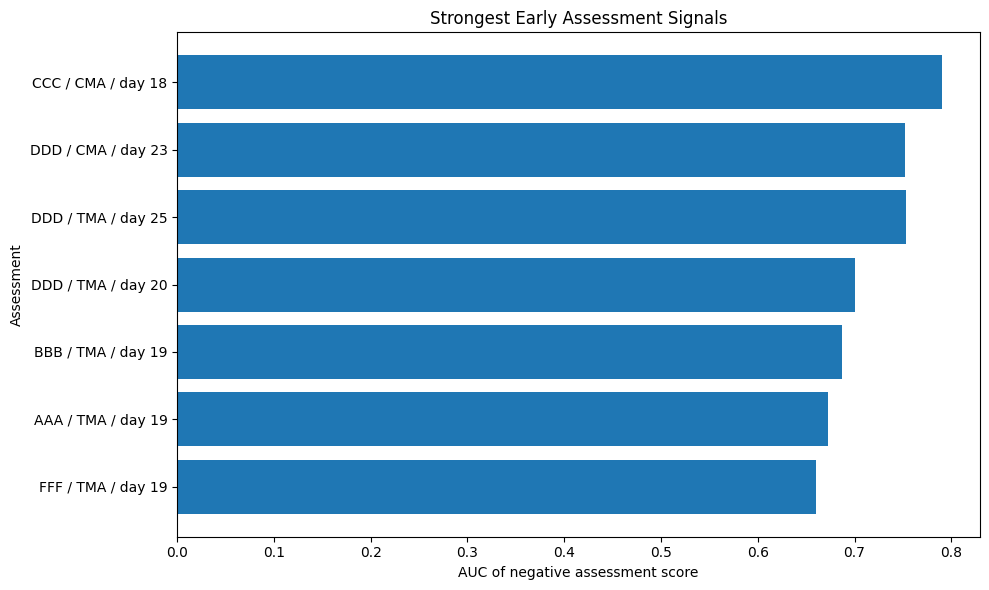

In [7]:
top_assessments = assessment_results.head(10).copy()

print(
    top_assessments[
        [
            "id_assessment",
            "code_module",
            "code_presentation",
            "assessment_type",
            "assessment_day",
            "students_with_scores",
            "not_at_risk_mean_score",
            "at_risk_mean_score",
            "risk_signal_auc",
        ]
    ].round(4).to_string(index=False)
)

plt.figure(figsize=(10, 6))
plot_assessments = top_assessments.sort_values("risk_signal_auc")

labels = (
    plot_assessments["code_module"].astype(str)
    + " / "
    + plot_assessments["assessment_type"].astype(str)
    + " / day "
    + plot_assessments["assessment_day"].astype(int).astype(str)
)

plt.barh(labels, plot_assessments["risk_signal_auc"])
plt.xlabel("AUC of negative assessment score")
plt.ylabel("Assessment")
plt.title("Strongest Early Assessment Signals")
plt.tight_layout()
plt.show()


## 5. Practical Implications for Student Success

The timing and checkpoint findings can be translated into a staged advising
workflow.

### First week

The Day-7 model already shows meaningful discrimination. This supports early
screening for students who show very low engagement or other early warning
signals.

### Second to third week

As additional activity and assessment information accumulates, the model's
predictive performance improves. Advisors can refine the priority list rather
than relying on the first-week signal alone.

### Around Day 18

The strongest individual early assessment signal found in this analysis is the
CCC / 2014B CMA at Day 18. Where comparable early checkpoints exist, assessment
performance can be used as an additional academic trigger for follow-up.

### By Day 28

The full early-warning feature set tested here reaches the strongest
performance among the four cutoffs. This is a strong point for a more
confident prioritization of limited advising resources.


## 6. Final Early-Warning Insight

The actual results close the two remaining case-study questions.

**How early?**

A meaningful signal appears as early as **Day 7 (AP 0.8027)** and improves
steadily to **Day 28 (AP 0.8716)**. Therefore, risk identification can begin
within the first week, while the fourth-week model provides the strongest
performance among the tested windows.

**Which checkpoint?**

The strongest individual early assessment signal is the **CCC / 2014B CMA at
Day 18**, with a risk-signal AUC of **0.7901** and a large difference between
the mean scores of at-risk and non-at-risk students.

Together, these findings support a practical strategy:

> **Start screening early, update risk as evidence accumulates, and use
> assessment checkpoints as targeted academic signals.**

The model is a decision-support system. It should help advisors prioritize
and investigate students; it should not be treated as a causal explanation
or an automatic decision about a student's future.


In [8]:
timing_path = PROCESSED_DIR / "early_warning_timing.csv"
assessment_path = PROCESSED_DIR / "assessment_checkpoint_signals.csv"

timing_results.to_csv(timing_path, index=False)
assessment_results.to_csv(assessment_path, index=False)

print("Saved:", timing_path)
print("Saved:", assessment_path)


Saved: d:\Early Risk Detection for Student Success - OULAD\data\processed\early_warning_timing.csv
Saved: d:\Early Risk Detection for Student Success - OULAD\data\processed\assessment_checkpoint_signals.csv


## 7. Notebook Summary

### What this notebook established

- Useful early-risk prediction is already possible by **Day 7**.
- Predictive performance improves across the tested **Day 7, 14, 21, and 28**
  windows.
- **Day 28** gives the strongest tested Random Forest performance.
- The strongest individual early checkpoint is **CCC / 2014B / CMA at Day 18**.
- The results provide concrete timing and assessment evidence for the
  Student Success Office.
- All conclusions are based on the actual outputs from the timing and
  checkpoint analyses.

### Handoff to the stakeholder report

Notebook 07 can use these results to complete the case-study narrative around
**when to intervene** and **which academic checkpoints deserve attention**.
